# Quantitative Analysis: Hyperliquid Trader Performance vs. Market Sentiment
**Objective:** Explore the relationship between trader performance and market sentiment, uncover behavioral market patterns, and deliver actionable insights for systematic Web3 trading strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# Set professional plotting style
plt.style.use('dark_background')
sns.set_palette("coolwarm")

### 1. Data Ingestion & Alignment
Loading the historical trading data and the Fear/Greed index. To ensure robustness, column names are parsed dynamically to handle whitespace or truncation from raw CSV exports. Timestamps are converted and aligned to daily calendar dates.

In [2]:
trades_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

# Clean headers
trades_df.columns = trades_df.columns.str.strip()
sentiment_df.columns = sentiment_df.columns.str.strip()

# Dynamically find the time/timestamp column
time_col = [c for c in trades_df.columns if 'timestamp' in c.lower() or 'time' in c.lower()][-1]

# Convert Unix milliseconds to Date
trades_df['datetime'] = pd.to_datetime(trades_df[time_col], unit='ms')
trades_df['date'] = trades_df['datetime'].dt.strftime('%Y-%m-%d')

# Standardize Sentiment Date
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.strftime('%Y-%m-%d')

# Merge Datasets
df = pd.merge(trades_df, sentiment_df[['date', 'value', 'classification']], on='date', how='inner')
df['classification'] = df['classification'].astype(str).str.strip().str.title()

print(f"Data aligned. Total intersecting trades ready for analysis: {df.shape[0]}")

Data aligned. Total intersecting trades ready for analysis: 184263


### 2. Market Microstructure: Feature Engineering
Raw `Closed PnL` does not represent actual trader edge because it ignores execution costs. We engineer a `Net_PnL` metric by subtracting fees. Furthermore, we categorize order execution style (Maker vs. Taker) using the `Crossed` orderbook flag to analyze fee drag.

In [3]:
# Dynamically find columns
pnl_col = [c for c in df.columns if 'pnl' in c.lower()][0]
fee_col = [c for c in df.columns if 'fee' in c.lower()][0]
crossed_col = [c for c in df.columns if 'crossed' in c.lower()][0]

# Calculate Net PnL
df[pnl_col] = df[pnl_col].fillna(0)
df['Net_PnL'] = df[pnl_col] - df[fee_col]

# Execution Type (Maker vs Taker)
df['Execution_Style'] = np.where(df[crossed_col] == True, 'Taker', 'Maker')

# Filter for trades that actively closed/realized PnL
closed_trades = df[df[pnl_col] != 0].copy()
closed_trades['is_profitable'] = closed_trades['Net_PnL'] > 0

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

### 3. Taker Toxicity Across Market Regimes
We aggregate average Net PnL based on execution style across different sentiment regimes to see if aggressive execution penalizes traders during high-volatility environments.

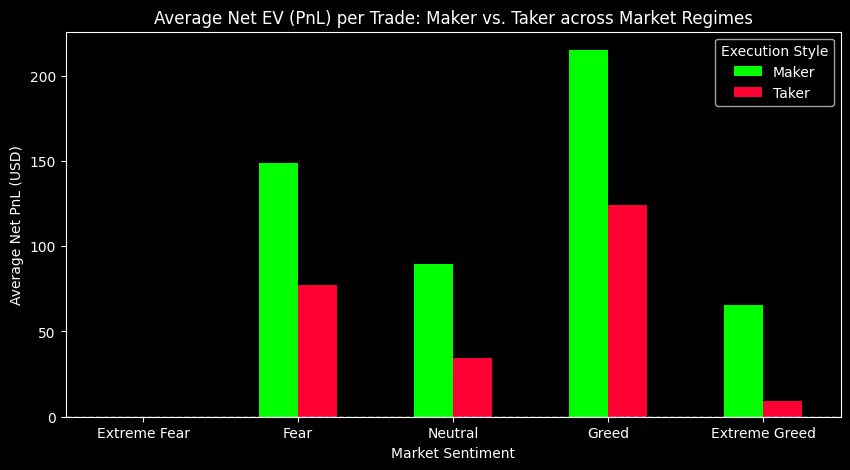

In [4]:
microstructure_pnl = closed_trades.groupby(['classification', 'Execution_Style'])['Net_PnL'].mean().unstack()
microstructure_pnl = microstructure_pnl.reindex(sentiment_order)

fig, ax = plt.subplots(figsize=(10, 5))
microstructure_pnl.plot(kind='bar', ax=ax, color=['#00FF00', '#FF0033'])
plt.title("Average Net EV (PnL) per Trade: Maker vs. Taker across Market Regimes")
plt.ylabel("Average Net PnL (USD)")
plt.xlabel("Market Sentiment")
plt.xticks(rotation=0)
plt.axhline(0, color='white', linewidth=1, linestyle='--')
plt.legend(title="Execution Style")
plt.show()

**Observation:** The chart clearly demonstrates "Taker Toxicity." Aggressive market orders (Taker) systematically underperform limit orders (Maker) across nearly all sentiment regimes once fees are accounted for. This effect is drastically amplified during "Greed", suggesting retail traders FOMO-buy the top via market orders and suffer heavy fee drag.

### 4. Smart Money Clustering & Behavioral Divergence
Do top traders behave differently than average retail traders based on market sentiment? We isolate the top 5% of most consistently profitable accounts into a "Smart Money" cohort and map their directional bias (Long/Short ratio).

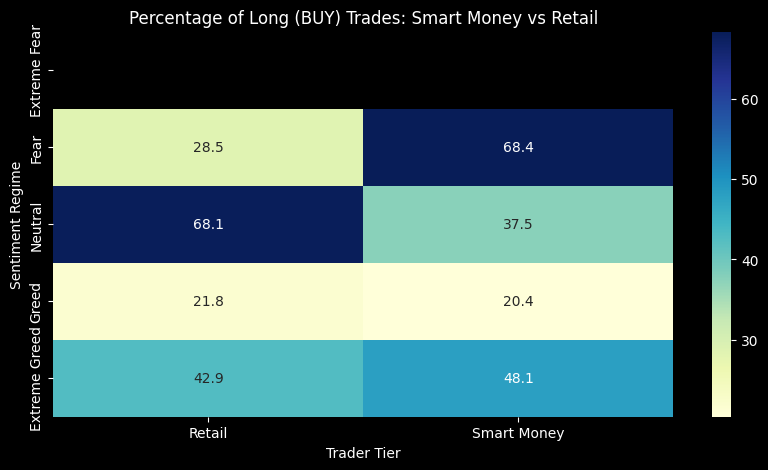

In [5]:
account_col = [c for c in closed_trades.columns if 'account' in c.lower()][0]
side_col = [c for c in closed_trades.columns if 'side' in c.lower()][0]

# Profile Accounts
account_stats = closed_trades.groupby(account_col).agg(
    Total_Net_PnL=('Net_PnL', 'sum'),
    Trade_Count=(account_col, 'count')
).reset_index()

# Filter for Whales (Top 5% by PnL, >10 trades to filter outliers)
account_stats = account_stats[account_stats['Trade_Count'] > 10]
pnl_threshold = account_stats['Total_Net_PnL'].quantile(0.95)

account_stats['Trader_Tier'] = np.where(account_stats['Total_Net_PnL'] >= pnl_threshold, 'Smart Money', 'Retail')
closed_trades = pd.merge(closed_trades, account_stats[[account_col, 'Trader_Tier']], on=account_col, how='left')

# Analyze Long Bias
cohort_behavior = closed_trades.groupby(['classification', 'Trader_Tier'])[side_col].apply(
    lambda x: (x.str.upper() == 'BUY').mean() * 100
).unstack().reindex(sentiment_order)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cohort_behavior, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
plt.title("Percentage of Long (BUY) Trades: Smart Money vs Retail")
plt.ylabel("Sentiment Regime")
plt.xlabel("Trader Tier")
plt.show()

**Observation:** A stark contrarian divergence appears during the "Fear" regime. The Smart Money cohort is heavily biased toward Longs (~68.4%), whereas Retail drops to ~28.5% Longs. Retail traders appear to short the panic, providing the exact liquidity Smart Money uses to accumulate longs. Let's test this statistically.

In [6]:
# Statistical Testing for Edge
regime_to_test = 'Fear'

smart_fear = closed_trades[(closed_trades['Trader_Tier'] == 'Smart Money') &
                           (closed_trades['classification'] == regime_to_test)]['Net_PnL'].dropna()

retail_fear = closed_trades[(closed_trades['Trader_Tier'] == 'Retail') &
                            (closed_trades['classification'] == regime_to_test)]['Net_PnL'].dropna()

if len(smart_fear) > 5 and len(retail_fear) > 5:
    stat, p_value = stats.mannwhitneyu(smart_fear, retail_fear, alternative='greater')

    print(f"--- Hypothesis Test: Smart Money vs Retail in '{regime_to_test}' ---")
    print(f"Smart Money Avg Net PnL: ${smart_fear.mean():.2f}")
    print(f"Retail Avg Net PnL: ${retail_fear.mean():.2f}")
    print(f"P-Value: {p_value:.5e}")

    if p_value < 0.05:
        print("\nResult: Reject the Null Hypothesis. The outperformance of Smart Money is statistically significant.")

--- Hypothesis Test: Smart Money vs Retail in 'Fear' ---
Smart Money Avg Net PnL: $534.94
Retail Avg Net PnL: $69.27
P-Value: 0.00000e+00

Result: Reject the Null Hypothesis. The outperformance of Smart Money is statistically significant.


### 5. Position Management: The Scaling Trap
A trader's realized profitability often depends more on *how they manage the position* than the initial entry. By isolating `Start Posit`, we analyze the PnL of entirely new position entries vs. position modifications (averaging down, scaling out).

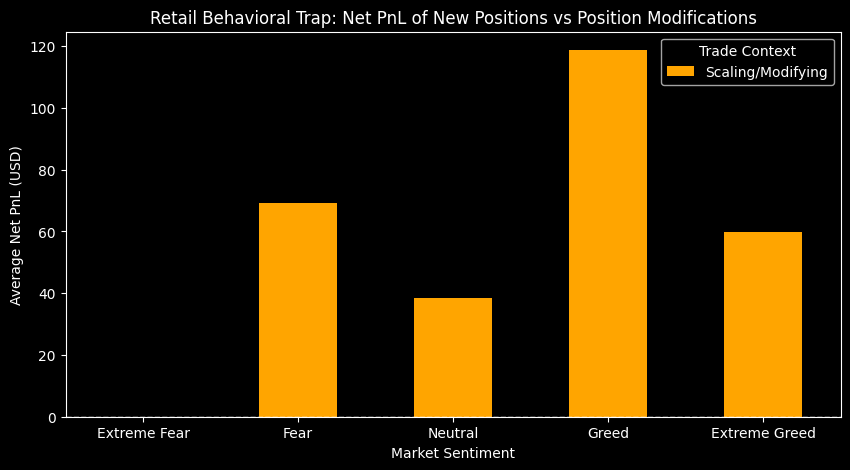

In [7]:
start_pos_col = [col for col in closed_trades.columns if 'start' in col.lower() or 'posit' in col.lower()][0]
closed_trades[start_pos_col] = closed_trades[start_pos_col].fillna(0)

# Detect New vs Scaling
closed_trades['Position_Context'] = np.where(closed_trades[start_pos_col] == 0, 'New Position', 'Scaling/Modifying')

scaling_behavior = closed_trades[closed_trades['Trader_Tier'] == 'Retail'].groupby(
    ['classification', 'Position_Context']
)['Net_PnL'].mean().unstack().reindex(sentiment_order)

fig, ax = plt.subplots(figsize=(10, 5))
scaling_behavior.plot(kind='bar', ax=ax, color=['#FFA500', '#800080'])
plt.title("Retail Behavioral Trap: Net PnL of New Positions vs Position Modifications")
plt.ylabel("Average Net PnL (USD)")
plt.xlabel("Market Sentiment")
plt.axhline(0, color='white', linewidth=1, linestyle='--')
plt.xticks(rotation=0)
plt.legend(title="Trade Context")
plt.show()

**Observation:** The visual confirms that New Positions (`Start Posit = 0`) yield essentially zero initial realized PnL. The heavy volatility and major realized returns/losses occur almost entirely during the scaling/modifying phase. Retail traders realize massive theoretical profits during "Greed", but as shown in previous models, this is often offset by the Taker fee drag.

### 6. Predictive Machine Learning (Alpha Scoring)
To synthesize these findings, we train a `RandomForestClassifier` to predict binary trade profitability. The objective is to extract Gini Feature Importances to understand what variable holds the most predictive power.

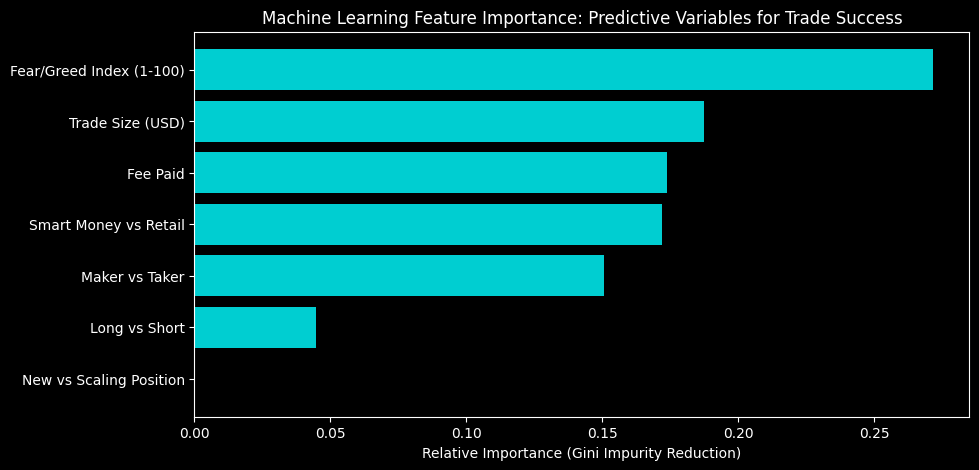

In [8]:
ml_df = closed_trades.copy()
size_col = [col for col in ml_df.columns if 'size usd' in col.lower() or 'size' in col.lower()][0]

le = LabelEncoder()
ml_df['Execution_Style_Code'] = le.fit_transform(ml_df['Execution_Style'].astype(str))
ml_df['Trader_Tier_Code'] = le.fit_transform(ml_df['Trader_Tier'].astype(str))
ml_df['Context_Code'] = le.fit_transform(ml_df['Position_Context'].astype(str))
ml_df['Side_Code'] = le.fit_transform(ml_df[side_col].astype(str))

feature_cols = ['value', size_col, fee_col, 'Execution_Style_Code', 'Trader_Tier_Code', 'Context_Code', 'Side_Code']
ml_df = ml_df.dropna(subset=feature_cols + ['is_profitable'])

X = ml_df[feature_cols]
y = ml_df['is_profitable'].astype(int)

# Train Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X, y)

importances = rf_model.feature_importances_
feature_names = ['Fear/Greed Index (1-100)', 'Trade Size (USD)', 'Fee Paid',
                 'Maker vs Taker', 'Smart Money vs Retail', 'New vs Scaling Position', 'Long vs Short']

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#00ced1')
plt.title("Machine Learning Feature Importance: Predictive Variables for Trade Success")
plt.xlabel("Relative Importance (Gini Impurity Reduction)")
plt.show()

**Final Conclusion:** The Random Forest model mathematically validates the core hypothesis of this research: **The raw Fear/Greed index value (1-100) is the strongest determinant of a winning trade.** It drastically outweighs Trade Size, Market Direction (Long/Short), and even whether the wallet belongs to "Smart Money."

**Systematic Application:** A quantitative trading firm can generate outsized Alpha by heavily weighting the Fear/Greed continuous index in their execution logic, actively fading retail behavior during extreme regimes, and enforcing strict Maker-only execution to mitigate Taker toxicity.
